<a href="https://colab.research.google.com/github/ADA-CompVision/SDP2022-brstcancer/blob/ralili/GAN/gan_models_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import argparse
import os
import numpy as np
import math
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import datasets
from torch.autograd import Variable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "gpu")

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rumiyyaalili","key":"ab121a81fb536037f0c3dd698d666bb2"}'}

In [6]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d theoviel/rsna-breast-cancer-256-pngs

Dataset URL: https://www.kaggle.com/datasets/theoviel/rsna-breast-cancer-256-pngs
License(s): CC0-1.0
100% 996M/998M [00:50<00:00, 21.3MB/s]
100% 998M/998M [00:50<00:00, 20.6MB/s]


In [8]:
!unzip -qq rsna-breast-cancer-256-pngs

In [9]:
# Create directories
os.makedirs("images", exist_ok=True)

In [10]:
import os

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Count all image files recursively
total_images = 0
for root, _, files in os.walk(dataset_path):
    total_images += sum(file.lower().endswith(extensions) for file in files)

print(f"Total number of images in the dataset: {total_images}")

Total number of images in the dataset: 54706


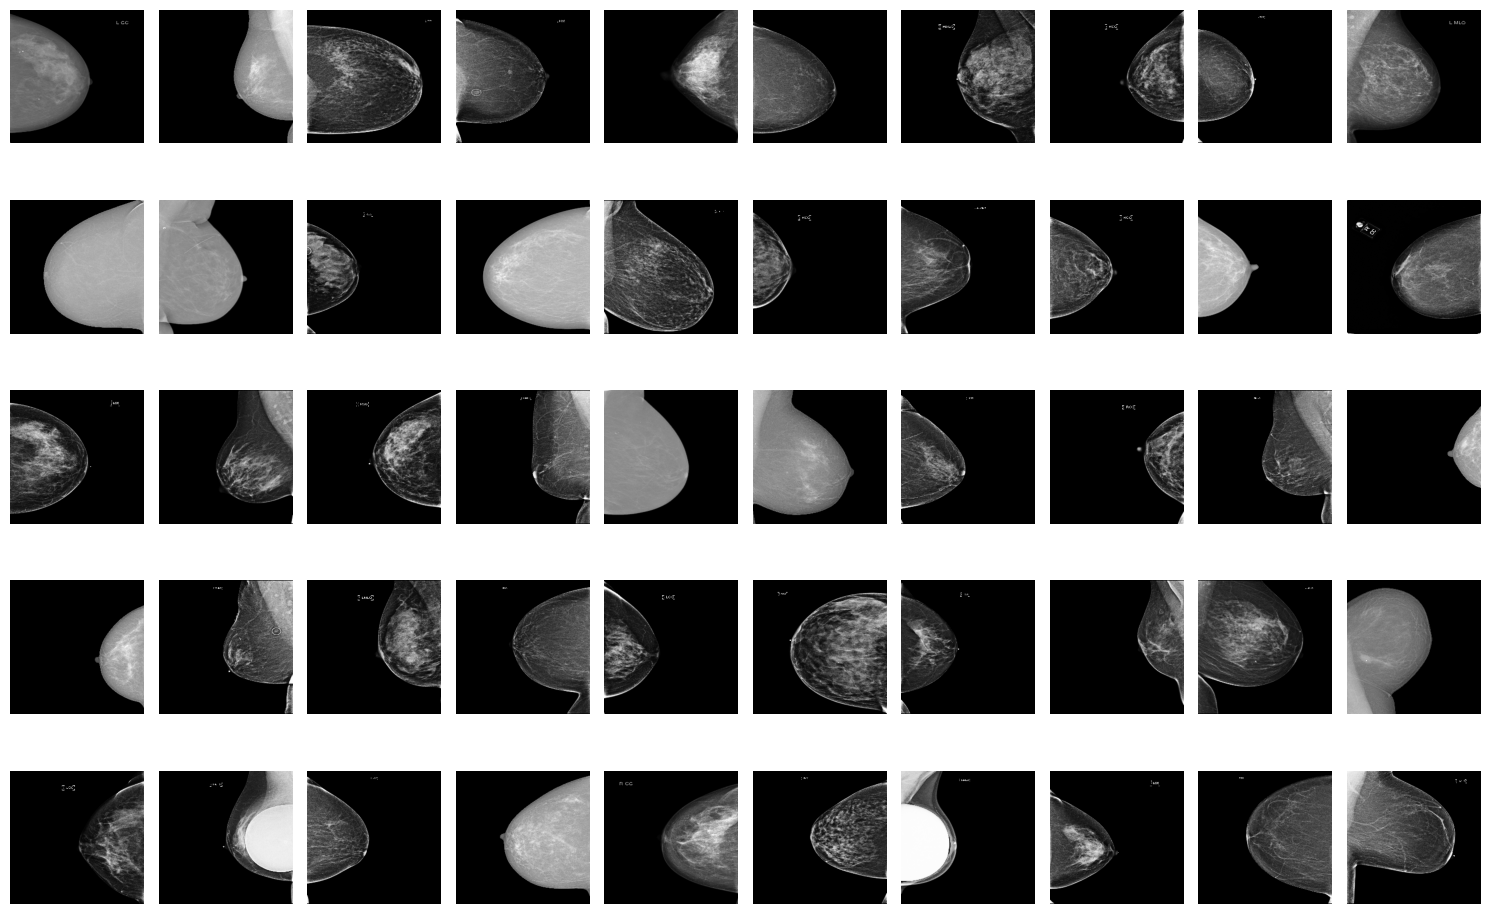

In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Get the first 50 image file paths
image_files = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(extensions):
            image_files.append(os.path.join(root, file))
        if len(image_files) >= 50:  # Stop after collecting 50 images
            break
    if len(image_files) >= 50:
        break

# Display the first 50 images
fig, axes = plt.subplots(5, 10, figsize=(15, 10))  # Create a 5x10 grid
axes = axes.flatten()

for img_path, ax in zip(image_files, axes):
    img = Image.open(img_path).convert("L")  # Convert to grayscale
    ax.imshow(img, cmap="gray")  # Display as grayscale
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
import os
from PIL import Image

# Paths
dataset_path = "/content"
aligned_dir = os.path.join(dataset_path, "aligned_images")
os.makedirs(aligned_dir, exist_ok=True)

def classify_breast(image):
    # Convert image to numpy array
    img_array = np.array(image)

    # Compute symmetry
    h, w = img_array.shape[:2]
    left_half = img_array[:, :w // 2]
    right_half = img_array[:, w // 2:]

    # Compute average pixel intensity (or other heuristics) for comparison
    left_mean = np.mean(left_half)
    right_mean = np.mean(right_half)

    # Example heuristic: If left side is brighter, it's a left breast image
    if left_mean > right_mean:
        return "LEFT"
    else:
        return "RIGHT"

In [13]:
# Process images
for img_file in os.listdir(dataset_path):
    if img_file.endswith(".png"):
        img_path = os.path.join(dataset_path, img_file)

        image = Image.open(img_path).convert("L")

        # Classify the image
        label = classify_breast(image)

        # Flip the image if it's a left breast
        if label == "LEFT":
            image = image.transpose(Image.FLIP_LEFT_RIGHT)  # Horizontal flip

        # Save the aligned image
        aligned_path = os.path.join(aligned_dir, img_file)
        image.save(aligned_path)

print(f"Alignment complete. Aligned images are saved in '{aligned_dir}'.")

Alignment complete. Aligned images are saved in '/content/aligned_images'.


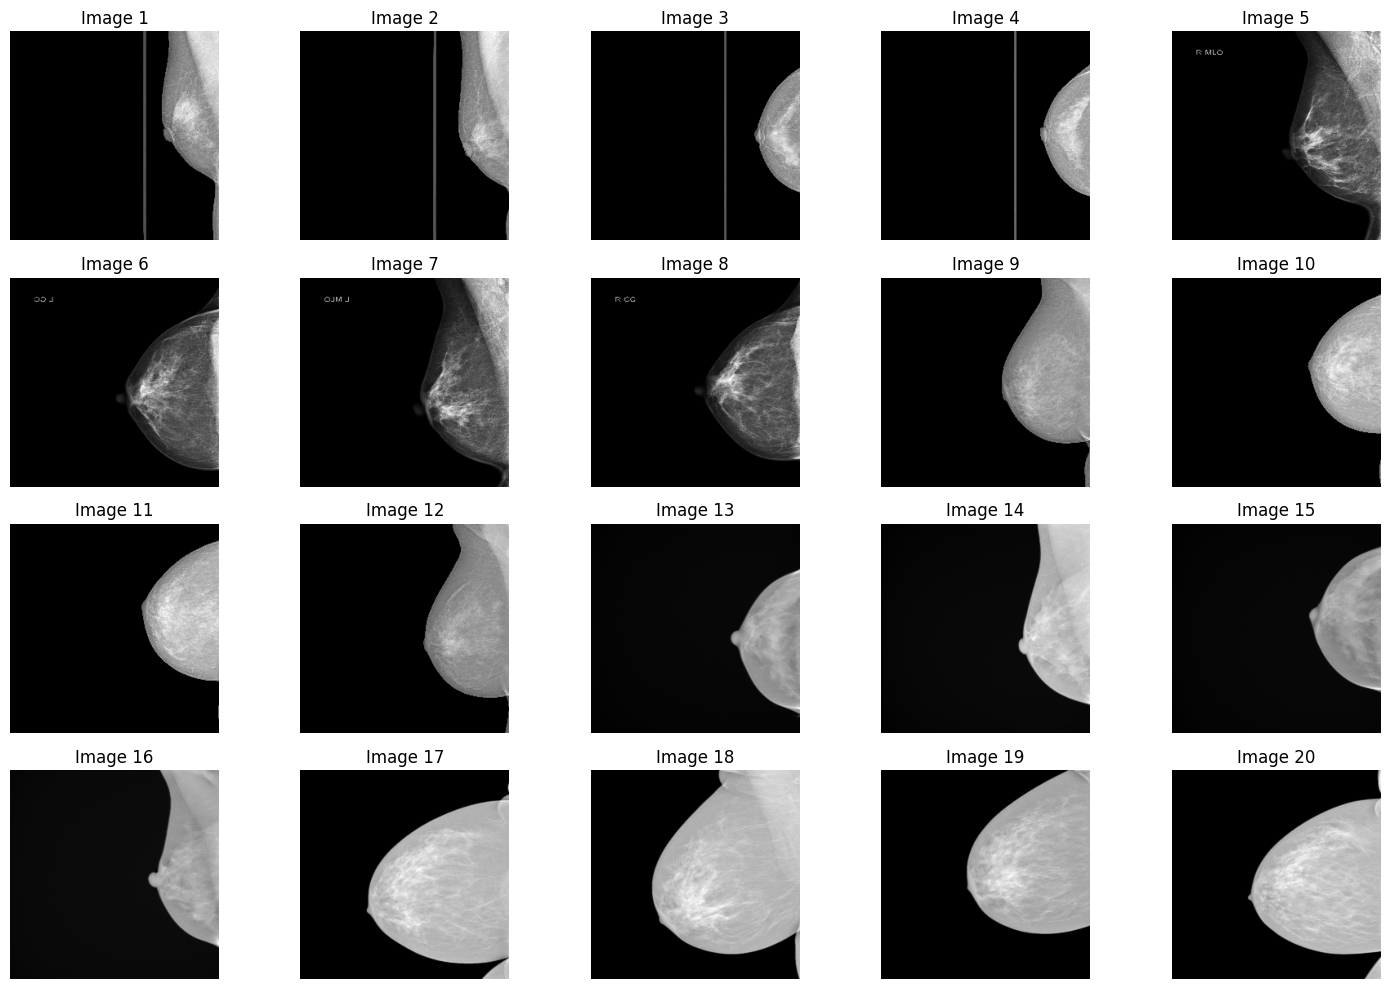

In [14]:
# Directory with aligned images
aligned_dir = "/content/aligned_images"

# Get the first 20 images
image_files = [f for f in os.listdir(aligned_dir) if f.endswith(".png")]
image_files = sorted(image_files)[:20]  # Sort to ensure consistent order

# Plot the images
plt.figure(figsize=(15, 10))
for i, img_file in enumerate(image_files):
    img_path = os.path.join(aligned_dir, img_file)
    image = Image.open(img_path)

    # Display each image in a grid
    plt.subplot(4, 5, i + 1)  # 4 rows, 5 columns for 20 images
    plt.imshow(image, cmap="gray")
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of bright, high-contrast images: 12714


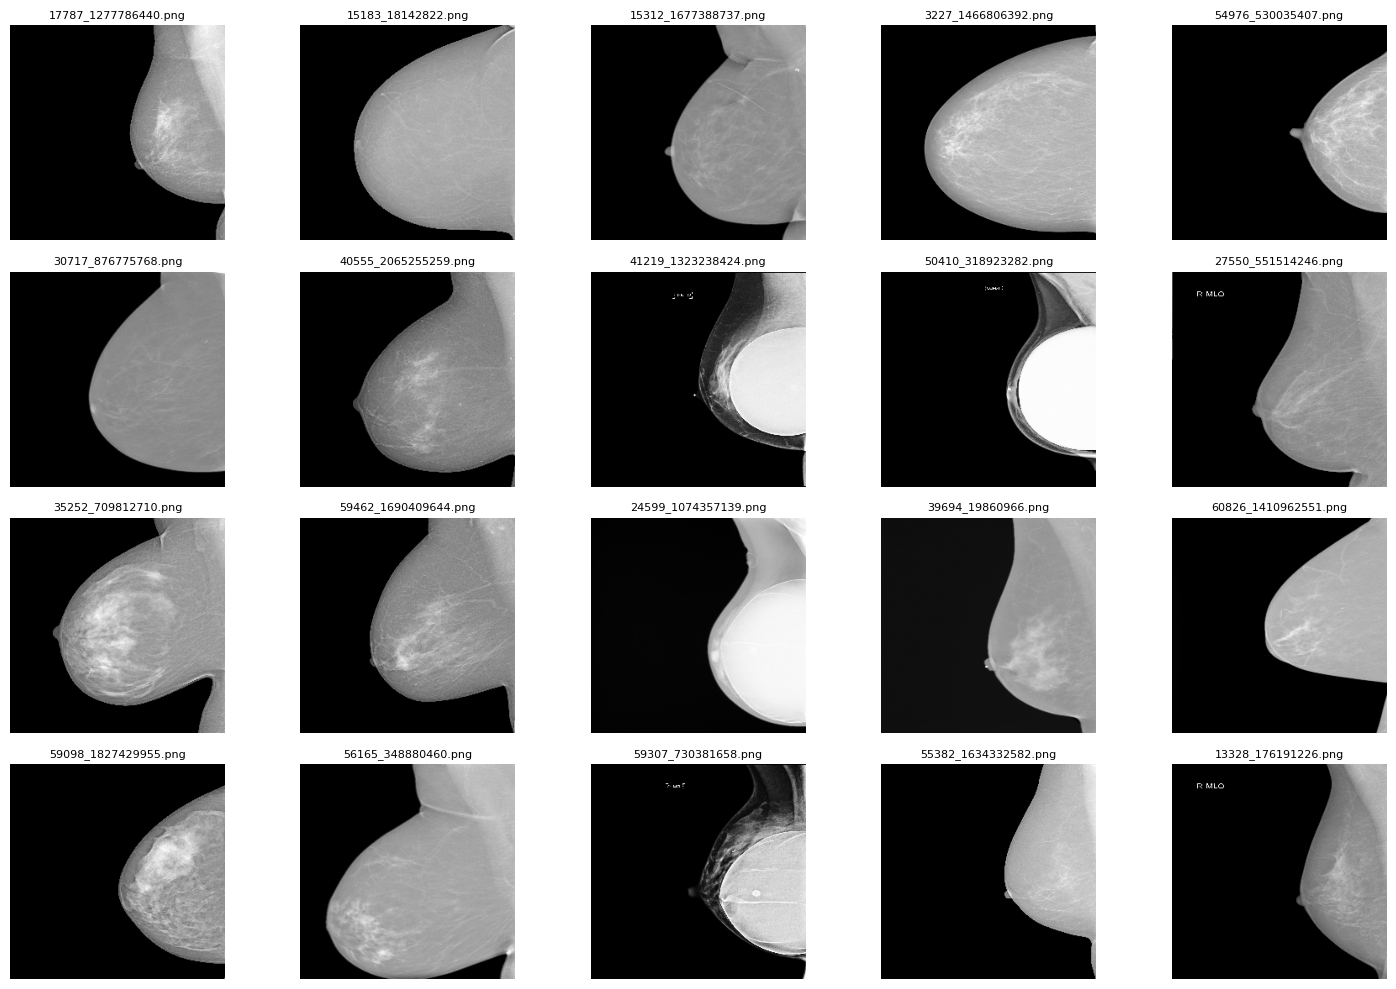

In [15]:
dataset_dir = "/content/aligned_images"

# thresholds for detecting high-contrast and bright images
brightness_threshold = 0.5  # Pixels brighter than this are considered white - increase for very bright regions
region_brightness_ratio = 0.15  # Proportion of image that must be bright to qualify - decrease if missing images with smaller bright areas
contrast_threshold = 0.2  # Minimum contrast difference to identify bright regions - decrease to include images with slightly less contrast

# function to identify high-contrast, bright images
def find_bright_contrast_images(dataset_dir, brightness_threshold, region_brightness_ratio, contrast_threshold):
    bright_images = []
    bright_filenames = []

    for filename in os.listdir(dataset_dir):
        if filename.endswith((".png")):
            # Load image
            img_path = os.path.join(dataset_dir, filename)
            img = Image.open(img_path)

            # Normalize pixel values to [0, 1]
            img_array = np.array(img) / 255.0

            # Calculate overall contrast (difference between max and min pixel intensities)
            contrast = np.max(img_array) - np.min(img_array)

            # Identify bright pixels
            bright_pixels = img_array >= brightness_threshold
            bright_pixel_ratio = np.sum(bright_pixels) / img_array.size

            # Check conditions for bright and high-contrast images
            if contrast > contrast_threshold and bright_pixel_ratio > region_brightness_ratio:
                bright_images.append(img)
                bright_filenames.append(filename)

    return bright_images, bright_filenames

# Identify high-intensity and high-contrast images
bright_images, bright_filenames = find_bright_contrast_images(
    dataset_dir, brightness_threshold, region_brightness_ratio, contrast_threshold
)

# Print the number of bright, high-contrast images
print(f"Number of bright, high-contrast images: {len(bright_images)}")

# Display the first 20 bright images
num_to_display = min(20, len(bright_images))
plt.figure(figsize=(15, 10))
for i in range(num_to_display):
    plt.subplot(4, 5, i + 1)  # 4 rows x 5 columns
    plt.imshow(bright_images[i], cmap="gray")
    plt.title(bright_filenames[i], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Remove identified images from the dataset directory
for filename in bright_filenames:
    img_path = os.path.join(dataset_dir, filename)
    try:
        os.remove(img_path)  # Delete the file
        if random.randint(0,300) == 123:
          print(f"Deleted {filename}")
    except Exception as e:
        print(f"Error deleting {filename}: {e}")

# Print the total number of images remaining in the directory
remaining_images = [filename for filename in os.listdir(dataset_dir) if filename.endswith((".png"))]
print(f"Total number of images remaining: {len(remaining_images)}")

Streaming output truncated to the last 5000 lines.
Error deleting 52394_628519936.png: name 'random' is not defined
Error deleting 55376_319295121.png: name 'random' is not defined
Error deleting 53914_239791638.png: name 'random' is not defined
Error deleting 34121_1395663574.png: name 'random' is not defined
Error deleting 55076_834128581.png: name 'random' is not defined
Error deleting 54552_2067071793.png: name 'random' is not defined
Error deleting 50955_1920341118.png: name 'random' is not defined
Error deleting 9228_1603963186.png: name 'random' is not defined
Error deleting 54420_1162874067.png: name 'random' is not defined
Error deleting 62221_937507255.png: name 'random' is not defined
Error deleting 43843_623907172.png: name 'random' is not defined
Error deleting 38838_328130212.png: name 'random' is not defined
Error deleting 25694_963461444.png: name 'random' is not defined
Error deleting 44186_1773037942.png: name 'random' is not defined
Error deleting 57791_345992349.png

In [38]:
# Set parameters
n_epochs = 300  # Number of epochs of training
batch_size = 64  # Size of the batches
lr_g = 0.0002  # Adam: learning rate for generator
lr_d = 0.0005 # learning rate for discriminator
b1 = 0.5  # Adam: decay of first-order momentum of gradient
b2 = 0.999  # Adam: decay of second-order momentum of gradient
latent_dim = 256  # Dimensionality of the latent space
img_size = 256  # Size of each image dimension
channels = 1  # Number of image channels (grayscale)
n_critic = 32  # Number of training steps for discriminator per iteration
clip_value = 0.01  # Lower and upper clip values for discriminator weights
sample_interval = 400  # Interval between image samples
lambda_gp = 10.0 # Define the gradient penalty weight

In [19]:
img_shape = (channels, img_size, img_size)
cuda = True if torch.cuda.is_available() else False

In [39]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.shape[0], 1, *self.img_shape)  # Ensure channel is 1 for grayscale
        return img

In [40]:
class Discriminator(nn.Module):
    def __init__(self, img_shape):
        super(Discriminator, self).__init__()
        img_flat_dim = int(np.prod(img_shape))  # This should be 65536 for 256x256 images

        self.model = nn.Sequential(
            nn.Linear(img_flat_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),  # Output a single value (real/fake)
        )

    def forward(self, img):
        img_flat = img.view(img.shape[0], -1)  # Flatten the image
        validity = self.model(img_flat)
        return validity

In [31]:
# import torch
# import torch.nn as nn

# class Generator(nn.Module):
#     def __init__(self, latent_dim=256):
#         super(Generator, self).__init__()

#         self.latent_dim = latent_dim

#         self.model = nn.Sequential(
#             # Fully connected layer
#             nn.Linear(latent_dim, 4096),  # 4096 = 4x4x256
#             nn.ReLU(),

#             # Reshape to (batch, channels, height, width) → (N, 256, 4, 4)
#             nn.Unflatten(1, (256, 4, 4)),

#             # Upsample to 8x8
#             nn.Upsample(scale_factor=2),
#             nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2, inplace=True),

#             # Upsample to 16x16
#             nn.Upsample(scale_factor=2),
#             nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(64),
#             nn.LeakyReLU(0.2, inplace=True),

#             # Upsample to 32x32
#             nn.Upsample(scale_factor=2),
#             nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(32),
#             nn.LeakyReLU(0.2, inplace=True),

#             # Upsample to 64x64
#             nn.Upsample(scale_factor=2),
#             nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(16),
#             nn.LeakyReLU(0.2, inplace=True),

#             # Upsample to 128x128
#             nn.Upsample(scale_factor=2),
#             nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(8),
#             nn.LeakyReLU(0.2, inplace=True),

#             # Upsample to 256x256
#             nn.Upsample(scale_factor=2),
#             nn.Conv2d(8, 1, kernel_size=3, stride=1, padding=1),

#             # Final activation function
#             nn.Tanh()  # Normalize output to [-1, 1] for GAN training
#         )

#     def forward(self, z):
#         return self.model(z)

# # Instantiate Generator
# latent_dim = 256
# generator = Generator(latent_dim)

# # Generate sample output
# test_z = torch.randn(1, latent_dim)  # Random latent vector
# output_img = generator(test_z)

# print("Generator output shape:", output_img.shape)  # Expected: torch.Size([1, 1, 256, 256])

Generator output shape: torch.Size([1, 1, 256, 256])


In [25]:
# import torch
# import torch.nn as nn

# class Discriminator(nn.Module):
#     def __init__(self, img_shape):
#         super(Discriminator, self).__init__()
#         channels, img_size, _ = img_shape  # (1, 256, 256)

#         self.model = nn.Sequential(
#             # 256 → 128, filters: 1 → 8
#             nn.Conv2d(channels, 8, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(8),
#             nn.LeakyReLU(0.2, inplace=True),

#             # 128 → 64, filters: 8 → 16
#             nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(16),
#             nn.LeakyReLU(0.2, inplace=True),

#             # 64 → 32, filters: 16 → 32
#             nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(32),
#             nn.LeakyReLU(0.2, inplace=True),

#             # 32 → 16, filters: 32 → 64
#             nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(64),
#             nn.LeakyReLU(0.2, inplace=True),

#             # 16 → 8, filters: 64 → 128
#             nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Dropout(0.3),  # Apply dropout here

#             # 8 → 4, filters: 128 → 256
#             nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(256),
#             nn.LeakyReLU(0.2, inplace=True),

#             # 4 → 1, Adaptive Pooling to fix Dense mismatch
#             nn.AdaptiveAvgPool2d(1),  # Output shape (batch, 256, 1, 1)

#             # Flatten and Dense
#             nn.Flatten(),
#             nn.Linear(256, 1)  # No need for 1024, since Adaptive Pooling ensures size 256
#         )

#     def forward(self, img):
#         validity = self.model(img)
#         return validity

# # Example usage
# img_shape = (1, 256, 256)
# discriminator = Discriminator(img_shape)

# test_img = torch.randn(1, *img_shape)  # Generate a random 256x256 image
# output = discriminator(test_img)
# print("Discriminator output shape:", output.shape)  # Expected: torch.Size([1, 1])

Discriminator output shape: torch.Size([1, 1])


In [41]:
# Directory of the dataset
dataset_dir = "/content/aligned_images"

# Custom Dataset Class to load images
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.png')]  # Filter jpg files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert('L')  # Open image and convert to Grayscale (1 channel)

        if self.transform:
            image = self.transform(image)

        return image

# Image transformation pipeline
transform = transforms.Compose([
    transforms.Resize(img_size),  # Resize to the target image size
    transforms.ToTensor(),  # Convert the image to tensor
    transforms.Normalize([0.5], [0.5])  # Normalize grayscale images to [-1, 1]
])

# Create DataLoader
dataset = CustomImageDataset(root_dir=dataset_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Check the first batch of images
for batch in dataloader:
    print(batch.shape)  # Should output (batch_size, 1, 256, 256) for Grayscale images
    break

torch.Size([64, 1, 256, 256])


In [42]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch

def generate_and_display_images(generator, num_images=25, latent_dim=100, nrow=5, device="cuda"):
    """
    Generate and display images using the trained generator.

    Args:
        generator (nn.Module): The trained generator model.
        num_images (int): Number of images to generate.
        latent_dim (int): Dimensionality of the latent space.
        nrow (int): Number of images per row in the grid.
        device (str): Device to perform computations on ("cuda" or "cpu").
    """
    generator.eval()  # Set generator to evaluation mode
    with torch.no_grad():  # No need to compute gradients
        # Generate latent vectors
        z = torch.randn(num_images, latent_dim).to(device)
        # Generate images
        generated_images = generator(z)

        # Debug: Print shape of generated images
        print("Generated images shape:", generated_images.shape)

        # Remove any extra dimensions if necessary
        if generated_images.dim() == 5:  # Check if there's an extra dimension
            generated_images = generated_images.squeeze(2)

        # Normalize and move to CPU for display
        generated_images = generated_images.cpu()

        # Display images using a grid
        grid = make_grid(generated_images, nrow=nrow, normalize=True)
        plt.figure(figsize=(10, 10))
        plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
        plt.axis("off")
        plt.show()

Generated images shape: torch.Size([7, 1, 1, 256, 256])


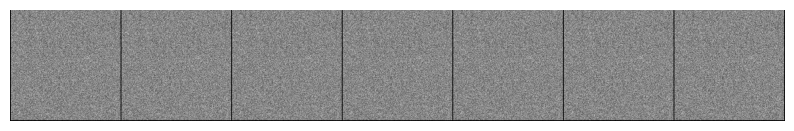

[Epoch 1/300] [D loss: -815.745300] [G loss: -393.650726]
[Epoch 2/300] [D loss: -72.811211] [G loss: -191.265137]
[Epoch 3/300] [D loss: -37.954941] [G loss: -92.152672]
[Epoch 4/300] [D loss: -35.522045] [G loss: -62.512871]
[Epoch 5/300] [D loss: -56.605461] [G loss: -61.380367]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


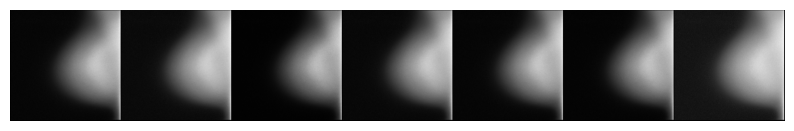

[Epoch 6/300] [D loss: -72.321060] [G loss: -34.580528]
[Epoch 7/300] [D loss: -60.285633] [G loss: -37.215866]
[Epoch 8/300] [D loss: -60.641617] [G loss: -40.701729]
[Epoch 9/300] [D loss: -82.658875] [G loss: -53.736824]
[Epoch 10/300] [D loss: -38.388100] [G loss: -1.048906]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


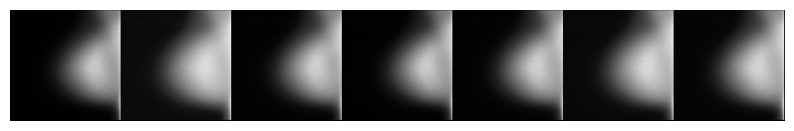

[Epoch 11/300] [D loss: -94.087341] [G loss: -12.949883]
[Epoch 12/300] [D loss: -62.324898] [G loss: -23.350883]
[Epoch 13/300] [D loss: -92.343155] [G loss: -27.976254]
[Epoch 14/300] [D loss: -58.389648] [G loss: -25.878592]
[Epoch 15/300] [D loss: -63.566509] [G loss: -23.876987]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


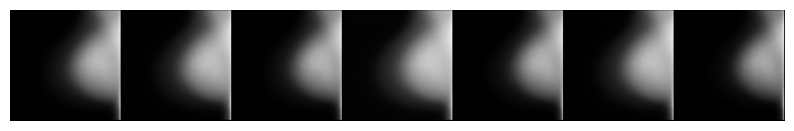

[Epoch 16/300] [D loss: -77.000465] [G loss: -18.387796]
[Epoch 17/300] [D loss: -53.458397] [G loss: -18.263622]
[Epoch 18/300] [D loss: -56.240654] [G loss: -7.973597]
[Epoch 19/300] [D loss: -69.274246] [G loss: -6.756624]
[Epoch 20/300] [D loss: -60.501068] [G loss: -29.416098]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


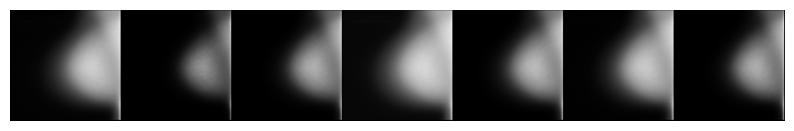

[Epoch 21/300] [D loss: -61.399162] [G loss: -19.146523]
[Epoch 22/300] [D loss: -66.094803] [G loss: -45.062344]
[Epoch 23/300] [D loss: -65.477478] [G loss: -23.825869]
[Epoch 24/300] [D loss: -66.516403] [G loss: -0.048954]
[Epoch 25/300] [D loss: -58.178322] [G loss: -16.056351]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


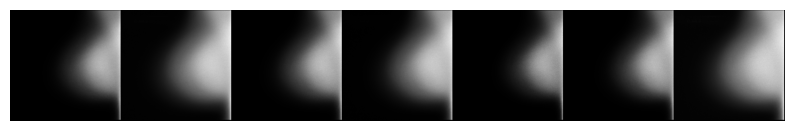

[Epoch 26/300] [D loss: -90.130455] [G loss: -23.490959]
[Epoch 27/300] [D loss: -66.704651] [G loss: -25.202255]
[Epoch 28/300] [D loss: -67.507675] [G loss: -29.539661]
[Epoch 29/300] [D loss: -56.850311] [G loss: -16.463831]
[Epoch 30/300] [D loss: -71.203094] [G loss: -26.462721]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


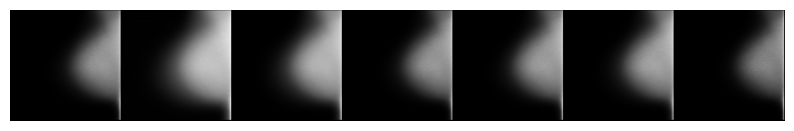

[Epoch 31/300] [D loss: -80.237480] [G loss: -26.855072]
[Epoch 32/300] [D loss: -68.478775] [G loss: -31.288992]
[Epoch 33/300] [D loss: -86.713028] [G loss: -30.671385]
[Epoch 34/300] [D loss: -79.897690] [G loss: -28.061577]
[Epoch 35/300] [D loss: -60.182739] [G loss: -31.706322]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


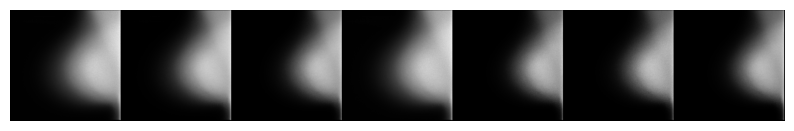

[Epoch 36/300] [D loss: -49.554684] [G loss: -43.591812]
[Epoch 37/300] [D loss: -51.592014] [G loss: -32.925442]
[Epoch 38/300] [D loss: -66.220383] [G loss: -37.023895]
[Epoch 39/300] [D loss: -55.167198] [G loss: -27.112566]
[Epoch 40/300] [D loss: -54.055767] [G loss: -21.299263]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


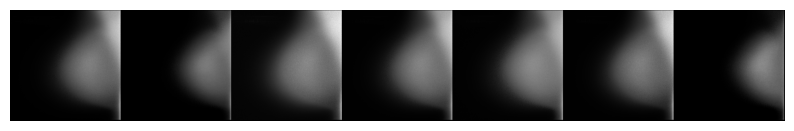

[Epoch 41/300] [D loss: -62.167450] [G loss: -8.797208]
[Epoch 42/300] [D loss: -66.537148] [G loss: -4.595316]
[Epoch 43/300] [D loss: -64.459198] [G loss: -20.418674]
[Epoch 44/300] [D loss: -76.879112] [G loss: -13.263112]
[Epoch 45/300] [D loss: -47.903358] [G loss: -10.760386]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


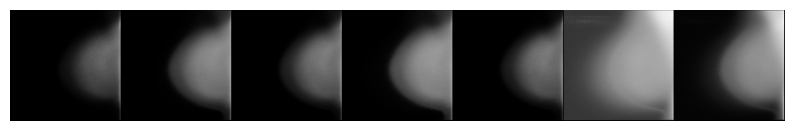

[Epoch 46/300] [D loss: -27.317919] [G loss: -14.247128]
[Epoch 47/300] [D loss: -50.007641] [G loss: -13.892529]
[Epoch 48/300] [D loss: -51.020515] [G loss: -20.624821]
[Epoch 49/300] [D loss: -80.339844] [G loss: -12.876475]
[Epoch 50/300] [D loss: -49.200851] [G loss: -8.586904]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


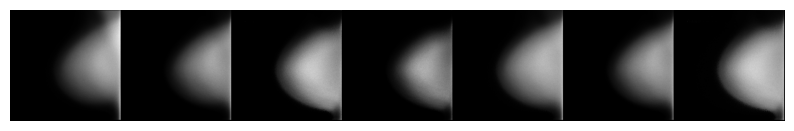

[Epoch 51/300] [D loss: -48.442837] [G loss: -23.063271]
[Epoch 52/300] [D loss: -29.980103] [G loss: -24.681044]
[Epoch 53/300] [D loss: -61.919098] [G loss: -15.707218]
[Epoch 54/300] [D loss: -57.676727] [G loss: -20.933498]
[Epoch 55/300] [D loss: -36.232307] [G loss: -9.535414]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


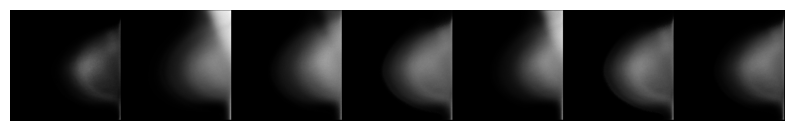

[Epoch 56/300] [D loss: -58.503006] [G loss: -9.012059]
[Epoch 57/300] [D loss: -51.405029] [G loss: -14.070965]
[Epoch 58/300] [D loss: -40.127991] [G loss: -26.697289]
[Epoch 59/300] [D loss: -71.216042] [G loss: -4.668474]
[Epoch 60/300] [D loss: -35.798851] [G loss: -22.148445]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


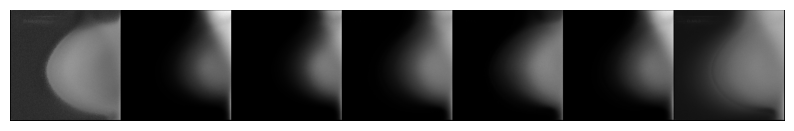

[Epoch 61/300] [D loss: -56.594078] [G loss: -11.599098]
[Epoch 62/300] [D loss: -43.033783] [G loss: -31.533348]
[Epoch 63/300] [D loss: -51.241898] [G loss: -18.030823]
[Epoch 64/300] [D loss: -66.495239] [G loss: -31.240152]
[Epoch 65/300] [D loss: -39.117889] [G loss: -41.353783]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


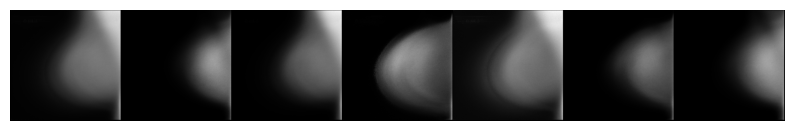

[Epoch 66/300] [D loss: -38.628319] [G loss: -22.878057]
[Epoch 67/300] [D loss: -53.680202] [G loss: -20.738304]
[Epoch 68/300] [D loss: -38.505127] [G loss: -54.331024]
[Epoch 69/300] [D loss: -78.177139] [G loss: -22.904024]
[Epoch 70/300] [D loss: -56.092834] [G loss: -11.892076]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


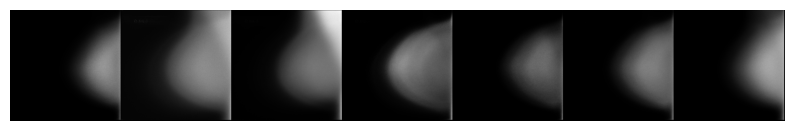

[Epoch 71/300] [D loss: -57.541225] [G loss: -37.834076]
[Epoch 72/300] [D loss: -47.836334] [G loss: -27.181492]
[Epoch 73/300] [D loss: -57.285805] [G loss: -25.362690]
[Epoch 74/300] [D loss: -26.393173] [G loss: -14.052643]
[Epoch 75/300] [D loss: -36.443371] [G loss: -0.859529]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


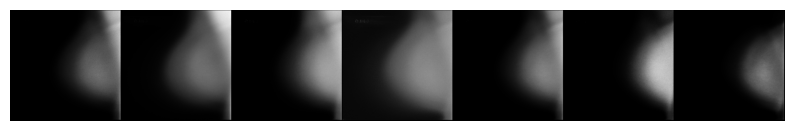

[Epoch 76/300] [D loss: -61.395142] [G loss: -2.613722]
[Epoch 77/300] [D loss: -63.891460] [G loss: -11.590490]
[Epoch 78/300] [D loss: -39.118206] [G loss: -21.171375]
[Epoch 79/300] [D loss: -35.825638] [G loss: -30.679581]
[Epoch 80/300] [D loss: -49.905342] [G loss: -20.909872]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


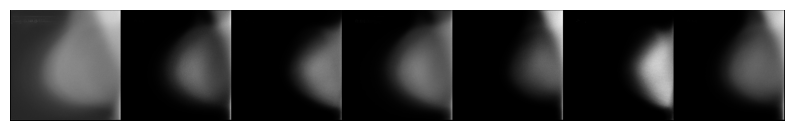

[Epoch 81/300] [D loss: -34.079865] [G loss: -9.779711]
[Epoch 82/300] [D loss: -39.388233] [G loss: -8.037034]
[Epoch 83/300] [D loss: -47.670815] [G loss: -16.022543]
[Epoch 84/300] [D loss: -40.962097] [G loss: -32.302422]
[Epoch 85/300] [D loss: -44.518082] [G loss: -23.719875]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


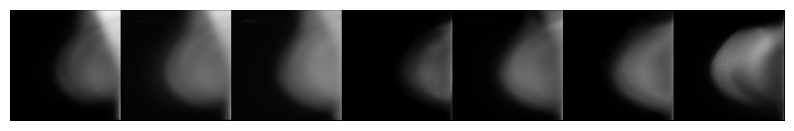

[Epoch 86/300] [D loss: -57.760914] [G loss: -6.594524]
[Epoch 87/300] [D loss: -27.603428] [G loss: -27.871443]
[Epoch 88/300] [D loss: -48.129112] [G loss: -34.973831]
[Epoch 89/300] [D loss: -40.744522] [G loss: -36.112087]
[Epoch 90/300] [D loss: -49.823692] [G loss: -7.538891]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


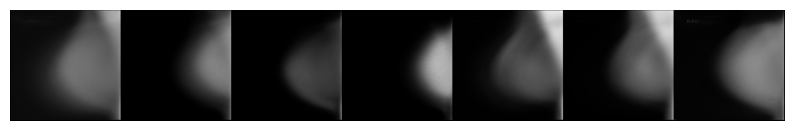

[Epoch 91/300] [D loss: -54.343193] [G loss: -14.064236]
[Epoch 92/300] [D loss: -35.570137] [G loss: -24.441013]
[Epoch 93/300] [D loss: -25.179386] [G loss: -20.270094]
[Epoch 94/300] [D loss: -47.113739] [G loss: -19.544651]
[Epoch 95/300] [D loss: -36.551411] [G loss: -27.661819]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


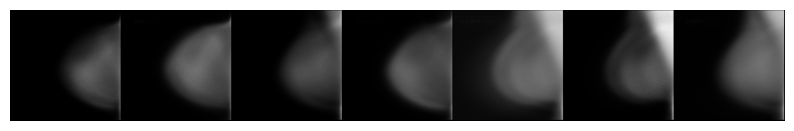

[Epoch 96/300] [D loss: -40.728317] [G loss: -14.435766]
[Epoch 97/300] [D loss: -39.477097] [G loss: -21.609591]
[Epoch 98/300] [D loss: -37.531082] [G loss: -5.245667]
[Epoch 99/300] [D loss: -31.727942] [G loss: -18.900297]
[Epoch 100/300] [D loss: -39.512634] [G loss: -11.673804]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


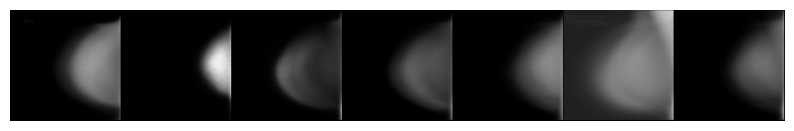

[Epoch 101/300] [D loss: -30.851994] [G loss: -12.999094]
[Epoch 102/300] [D loss: -53.992355] [G loss: -28.284908]
[Epoch 103/300] [D loss: -42.494133] [G loss: -18.141130]
[Epoch 104/300] [D loss: -34.703533] [G loss: -19.723198]
[Epoch 105/300] [D loss: -28.551117] [G loss: -17.903757]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


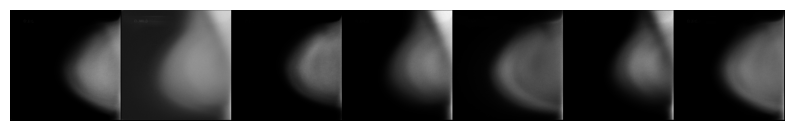

[Epoch 106/300] [D loss: -42.019341] [G loss: -21.220890]
[Epoch 107/300] [D loss: -47.669479] [G loss: -32.282433]
[Epoch 108/300] [D loss: -46.436737] [G loss: -28.135448]
[Epoch 109/300] [D loss: -28.556423] [G loss: -17.135576]
[Epoch 110/300] [D loss: -56.707031] [G loss: -16.259645]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


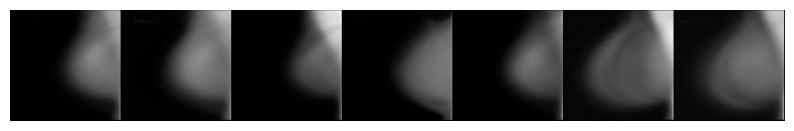

[Epoch 111/300] [D loss: -40.790977] [G loss: -26.391483]
[Epoch 112/300] [D loss: -37.636787] [G loss: -9.134596]
[Epoch 113/300] [D loss: -51.476601] [G loss: -22.476919]
[Epoch 114/300] [D loss: -45.600006] [G loss: -23.171177]
[Epoch 115/300] [D loss: -36.514404] [G loss: -33.158058]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


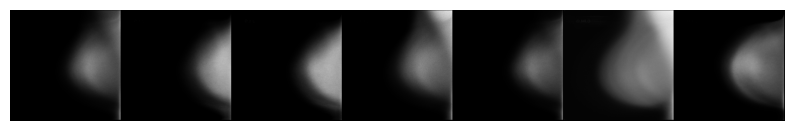

[Epoch 116/300] [D loss: -27.641567] [G loss: -2.781017]
[Epoch 117/300] [D loss: -45.780888] [G loss: -27.815659]
[Epoch 118/300] [D loss: -36.031471] [G loss: -16.808411]
[Epoch 119/300] [D loss: -21.245029] [G loss: -15.422437]
[Epoch 120/300] [D loss: -45.550793] [G loss: -17.891499]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


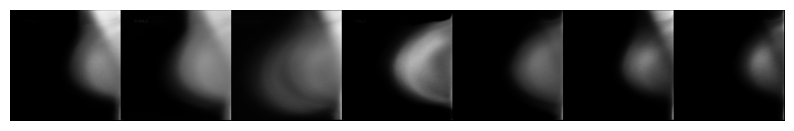

[Epoch 121/300] [D loss: -36.054405] [G loss: -31.135410]
[Epoch 122/300] [D loss: -35.565041] [G loss: -21.506737]
[Epoch 123/300] [D loss: -36.184105] [G loss: -19.549744]
[Epoch 124/300] [D loss: -53.953583] [G loss: -17.958220]
[Epoch 125/300] [D loss: -24.303696] [G loss: -36.775463]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


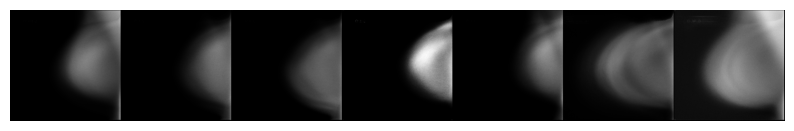

[Epoch 126/300] [D loss: -31.890289] [G loss: -20.184822]
[Epoch 127/300] [D loss: -27.770508] [G loss: 5.167910]
[Epoch 128/300] [D loss: -39.009102] [G loss: 1.027060]
[Epoch 129/300] [D loss: -53.240402] [G loss: -15.518597]
[Epoch 130/300] [D loss: -22.580231] [G loss: -19.105846]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


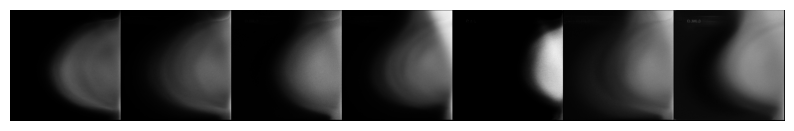

[Epoch 131/300] [D loss: -34.135086] [G loss: -14.602592]
[Epoch 132/300] [D loss: -31.388018] [G loss: -21.760937]
[Epoch 133/300] [D loss: -39.261440] [G loss: -10.684222]
[Epoch 134/300] [D loss: -26.624889] [G loss: -10.097189]
[Epoch 135/300] [D loss: -32.992676] [G loss: -22.987183]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


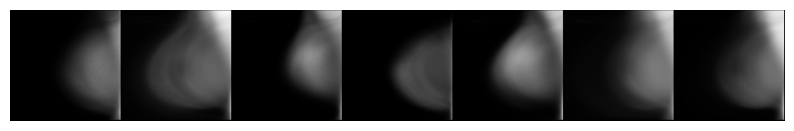

[Epoch 136/300] [D loss: -17.104059] [G loss: -10.452673]
[Epoch 137/300] [D loss: -30.235126] [G loss: -10.200782]
[Epoch 138/300] [D loss: -30.457607] [G loss: -9.753475]
[Epoch 139/300] [D loss: -49.781651] [G loss: -33.126682]
[Epoch 140/300] [D loss: -38.739075] [G loss: -21.090534]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


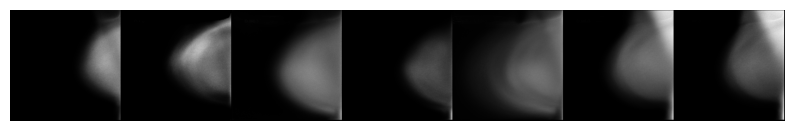

[Epoch 141/300] [D loss: -34.384121] [G loss: -4.275310]
[Epoch 142/300] [D loss: -35.033638] [G loss: -9.687901]
[Epoch 143/300] [D loss: -30.430212] [G loss: -11.754148]
[Epoch 144/300] [D loss: -35.824802] [G loss: -7.197183]
[Epoch 145/300] [D loss: -26.522308] [G loss: -23.744440]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


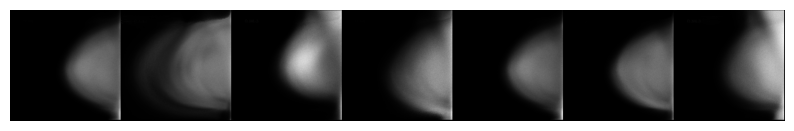

[Epoch 146/300] [D loss: -2.101954] [G loss: -10.538162]
[Epoch 147/300] [D loss: -29.639862] [G loss: -17.257627]
[Epoch 148/300] [D loss: -29.363880] [G loss: -10.737260]
[Epoch 149/300] [D loss: -38.968811] [G loss: -53.237175]
[Epoch 150/300] [D loss: -38.102814] [G loss: -20.184841]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


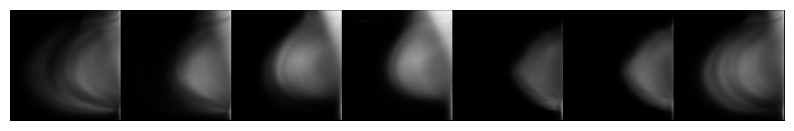

[Epoch 151/300] [D loss: -30.501471] [G loss: -17.950523]
[Epoch 152/300] [D loss: -23.378899] [G loss: -10.848881]
[Epoch 153/300] [D loss: -34.770199] [G loss: -11.688293]
[Epoch 154/300] [D loss: -33.814133] [G loss: -12.763182]
[Epoch 155/300] [D loss: -38.001392] [G loss: -8.769624]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


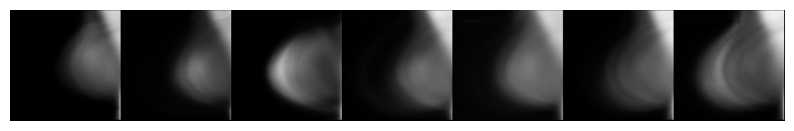

[Epoch 156/300] [D loss: -33.160950] [G loss: -14.398664]
[Epoch 157/300] [D loss: -41.406975] [G loss: -6.517765]
[Epoch 158/300] [D loss: -26.460442] [G loss: -0.027485]
[Epoch 159/300] [D loss: -31.244577] [G loss: -13.616800]
[Epoch 160/300] [D loss: -24.618969] [G loss: -4.670452]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


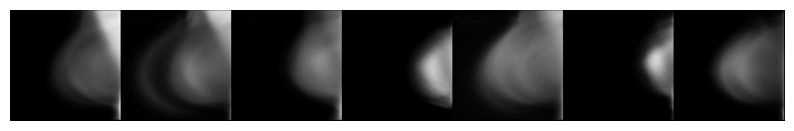

[Epoch 161/300] [D loss: -26.220173] [G loss: -8.401689]
[Epoch 162/300] [D loss: -34.844936] [G loss: -8.984016]
[Epoch 163/300] [D loss: -37.453796] [G loss: -13.183326]
[Epoch 164/300] [D loss: -32.015793] [G loss: -2.779062]
[Epoch 165/300] [D loss: -33.493092] [G loss: -25.193745]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


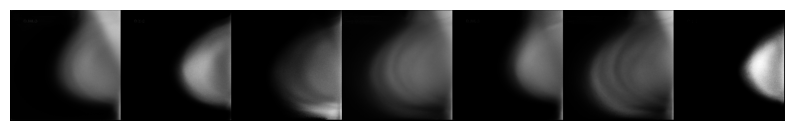

[Epoch 166/300] [D loss: -25.931049] [G loss: -7.716037]
[Epoch 167/300] [D loss: -27.485697] [G loss: -7.933779]
[Epoch 168/300] [D loss: -32.893600] [G loss: -10.845253]
[Epoch 169/300] [D loss: -35.207321] [G loss: -13.572304]
[Epoch 170/300] [D loss: -27.063133] [G loss: -6.132531]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


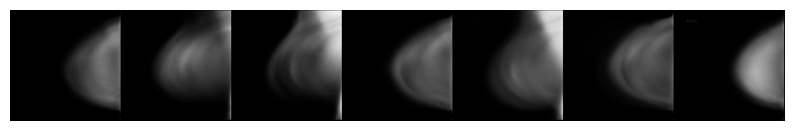

[Epoch 171/300] [D loss: -29.792580] [G loss: -1.996554]
[Epoch 172/300] [D loss: -33.267532] [G loss: -5.083059]
[Epoch 173/300] [D loss: -34.253002] [G loss: -16.153332]
[Epoch 174/300] [D loss: -17.993095] [G loss: -6.630689]
[Epoch 175/300] [D loss: -26.958700] [G loss: -24.245087]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


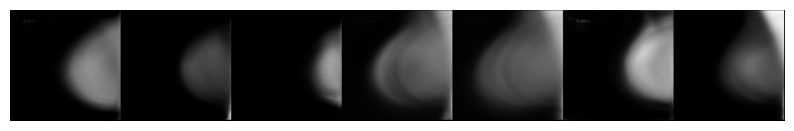

[Epoch 176/300] [D loss: -30.714882] [G loss: -20.326960]
[Epoch 177/300] [D loss: -13.991119] [G loss: -12.615515]
[Epoch 178/300] [D loss: -40.404621] [G loss: -14.374590]
[Epoch 179/300] [D loss: -29.754881] [G loss: -23.763670]
[Epoch 180/300] [D loss: -29.863476] [G loss: -10.461445]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


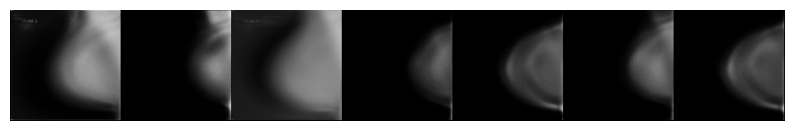

[Epoch 181/300] [D loss: -32.756241] [G loss: -2.922013]
[Epoch 182/300] [D loss: -23.709364] [G loss: -13.159547]
[Epoch 183/300] [D loss: -26.946274] [G loss: -12.741085]
[Epoch 184/300] [D loss: -25.121147] [G loss: -8.409492]
[Epoch 185/300] [D loss: -26.660515] [G loss: -4.407801]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


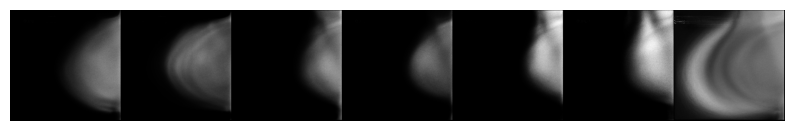

[Epoch 186/300] [D loss: -27.342777] [G loss: -6.252308]
[Epoch 187/300] [D loss: -20.733608] [G loss: -15.489388]
[Epoch 188/300] [D loss: -24.934525] [G loss: -9.408841]
[Epoch 189/300] [D loss: -13.796773] [G loss: -20.296467]
[Epoch 190/300] [D loss: -29.175564] [G loss: -2.438949]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


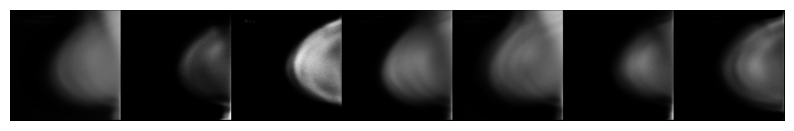

[Epoch 191/300] [D loss: -25.842388] [G loss: -8.106268]
[Epoch 192/300] [D loss: -29.000080] [G loss: -4.495050]
[Epoch 193/300] [D loss: -21.780327] [G loss: -6.037124]
[Epoch 194/300] [D loss: -25.576504] [G loss: -7.451597]
[Epoch 195/300] [D loss: -26.819584] [G loss: -8.523376]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


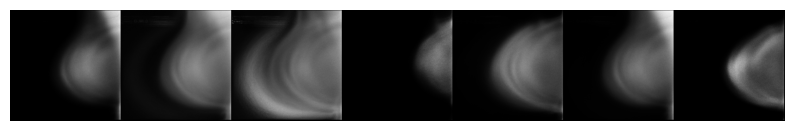

[Epoch 196/300] [D loss: -27.026384] [G loss: -7.140728]
[Epoch 197/300] [D loss: -25.596289] [G loss: -7.543303]
[Epoch 198/300] [D loss: -22.903341] [G loss: -9.853043]
[Epoch 199/300] [D loss: -29.321238] [G loss: -2.316438]
[Epoch 200/300] [D loss: -14.498873] [G loss: -6.783554]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


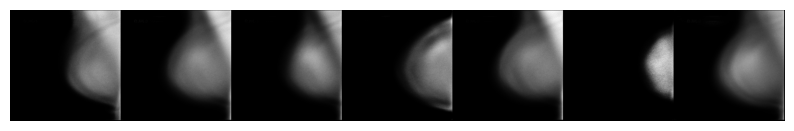

[Epoch 201/300] [D loss: -29.931816] [G loss: -0.338868]
[Epoch 202/300] [D loss: -27.806376] [G loss: -8.360636]
[Epoch 203/300] [D loss: -31.250114] [G loss: -11.775985]
[Epoch 204/300] [D loss: -27.379143] [G loss: -9.604889]
[Epoch 205/300] [D loss: -27.288059] [G loss: -9.387945]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


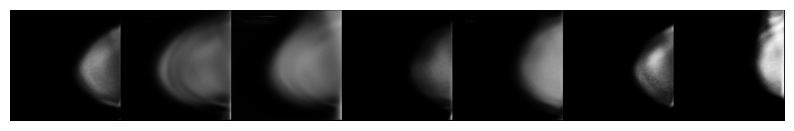

[Epoch 206/300] [D loss: -32.808311] [G loss: -10.497139]
[Epoch 207/300] [D loss: -31.655882] [G loss: -2.749405]
[Epoch 208/300] [D loss: -29.557867] [G loss: -3.791821]
[Epoch 209/300] [D loss: -24.221947] [G loss: -11.218472]
[Epoch 210/300] [D loss: -9.231715] [G loss: -10.532614]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


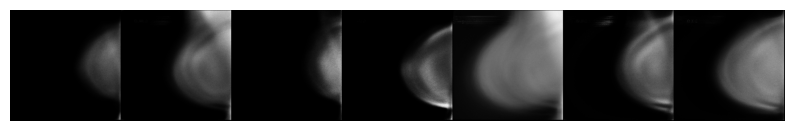

[Epoch 211/300] [D loss: -34.769009] [G loss: -3.643145]
[Epoch 212/300] [D loss: -26.568085] [G loss: -11.044006]
[Epoch 213/300] [D loss: -33.650215] [G loss: -6.789000]
[Epoch 214/300] [D loss: -27.170218] [G loss: -11.609415]
[Epoch 215/300] [D loss: -23.144709] [G loss: -6.336573]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


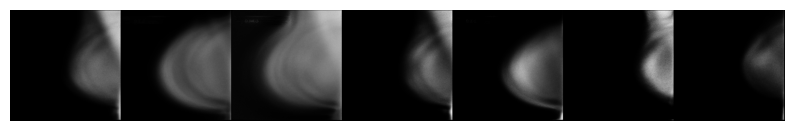

[Epoch 216/300] [D loss: -20.110785] [G loss: -5.447505]
[Epoch 217/300] [D loss: -24.070885] [G loss: -6.435231]
[Epoch 218/300] [D loss: -24.721281] [G loss: -8.163386]
[Epoch 219/300] [D loss: -20.898584] [G loss: -5.643908]
[Epoch 220/300] [D loss: -24.892441] [G loss: -13.800465]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


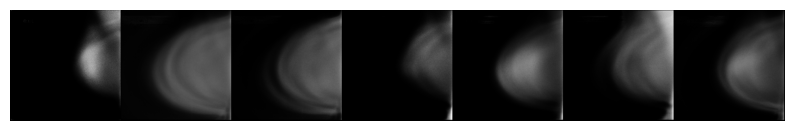

[Epoch 221/300] [D loss: -24.240841] [G loss: -4.531539]
[Epoch 222/300] [D loss: -25.336283] [G loss: -17.263865]
[Epoch 223/300] [D loss: -29.767979] [G loss: -5.399020]
[Epoch 224/300] [D loss: -19.240738] [G loss: -9.451347]
[Epoch 225/300] [D loss: -20.058971] [G loss: -9.271818]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


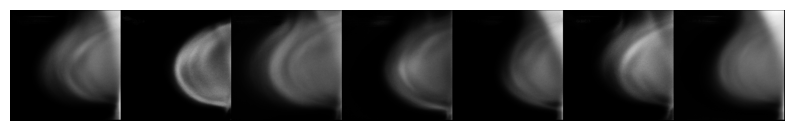

[Epoch 226/300] [D loss: -27.699341] [G loss: -9.908573]
[Epoch 227/300] [D loss: -21.179041] [G loss: -13.574453]
[Epoch 228/300] [D loss: -22.988739] [G loss: -7.728292]
[Epoch 229/300] [D loss: -21.627716] [G loss: -12.605106]
[Epoch 230/300] [D loss: -34.085655] [G loss: -11.938234]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


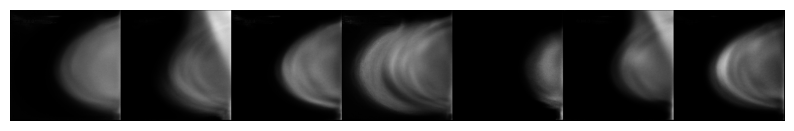

[Epoch 231/300] [D loss: -24.138668] [G loss: -7.404999]
[Epoch 232/300] [D loss: -26.123554] [G loss: -5.523127]
[Epoch 233/300] [D loss: -29.694597] [G loss: -9.657931]
[Epoch 234/300] [D loss: -30.506035] [G loss: -5.379311]
[Epoch 235/300] [D loss: -29.178848] [G loss: -7.850385]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


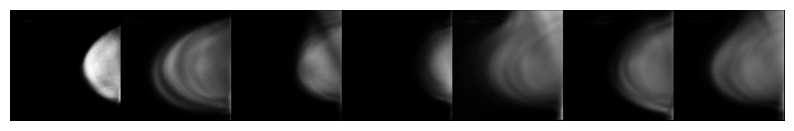

[Epoch 236/300] [D loss: -24.760609] [G loss: -9.179506]
[Epoch 237/300] [D loss: -22.736103] [G loss: -6.071421]
[Epoch 238/300] [D loss: -33.554123] [G loss: -7.245420]
[Epoch 239/300] [D loss: -20.504513] [G loss: -9.998186]
[Epoch 240/300] [D loss: -28.045994] [G loss: -12.253962]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


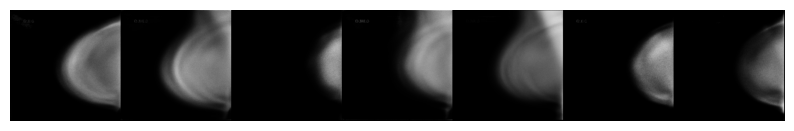

[Epoch 241/300] [D loss: -30.248041] [G loss: -10.494603]
[Epoch 242/300] [D loss: -16.748997] [G loss: -11.236019]
[Epoch 243/300] [D loss: -30.389893] [G loss: -3.508794]
[Epoch 244/300] [D loss: -33.295223] [G loss: -2.712145]
[Epoch 245/300] [D loss: -21.826450] [G loss: -1.078655]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


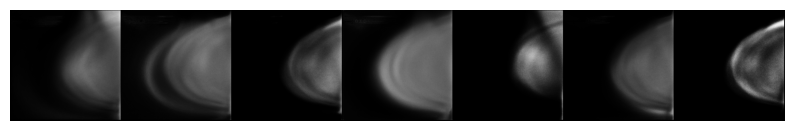

[Epoch 246/300] [D loss: -20.278446] [G loss: -3.540500]
[Epoch 247/300] [D loss: -24.062191] [G loss: -9.285089]
[Epoch 248/300] [D loss: -23.369692] [G loss: -10.566580]
[Epoch 249/300] [D loss: -27.783108] [G loss: -3.480508]
[Epoch 250/300] [D loss: -19.673916] [G loss: -6.470849]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


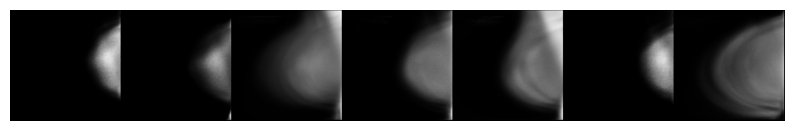

[Epoch 251/300] [D loss: -23.847828] [G loss: -10.291988]
[Epoch 252/300] [D loss: -17.535135] [G loss: -5.127782]
[Epoch 253/300] [D loss: -27.332907] [G loss: -5.774224]
[Epoch 254/300] [D loss: -13.595166] [G loss: -7.024035]
[Epoch 255/300] [D loss: -19.147392] [G loss: -4.441365]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


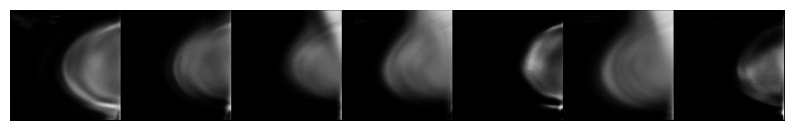

[Epoch 256/300] [D loss: -19.289377] [G loss: -8.052794]
[Epoch 257/300] [D loss: -23.529137] [G loss: -9.843662]
[Epoch 258/300] [D loss: -20.288555] [G loss: -5.757770]
[Epoch 259/300] [D loss: -23.920834] [G loss: -8.996040]
[Epoch 260/300] [D loss: -21.135983] [G loss: -9.079174]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


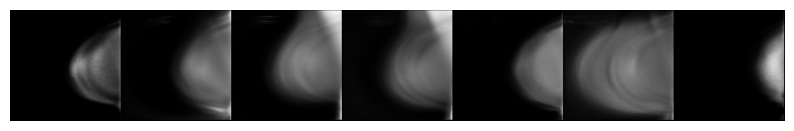

[Epoch 261/300] [D loss: -22.160984] [G loss: -12.895998]
[Epoch 262/300] [D loss: -19.962982] [G loss: -11.795856]
[Epoch 263/300] [D loss: -24.028242] [G loss: -5.984664]
[Epoch 264/300] [D loss: -27.125900] [G loss: -5.735785]
[Epoch 265/300] [D loss: -20.895691] [G loss: -8.073853]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


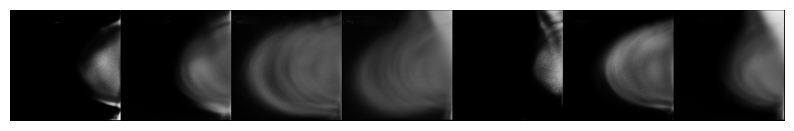

[Epoch 266/300] [D loss: -18.575466] [G loss: -5.289969]
[Epoch 267/300] [D loss: -15.815937] [G loss: -11.757017]
[Epoch 268/300] [D loss: -25.310455] [G loss: -8.525267]
[Epoch 269/300] [D loss: -22.570660] [G loss: -6.911510]
[Epoch 270/300] [D loss: -23.744301] [G loss: -10.245692]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


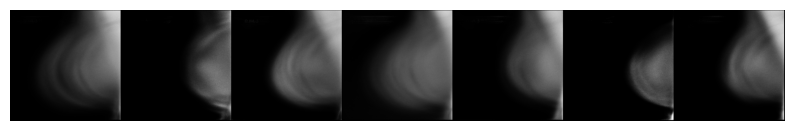

[Epoch 271/300] [D loss: -24.142443] [G loss: -8.920128]
[Epoch 272/300] [D loss: -15.855572] [G loss: -5.411445]
[Epoch 273/300] [D loss: -20.355255] [G loss: -6.435487]
[Epoch 274/300] [D loss: -19.288353] [G loss: 3.334119]
[Epoch 275/300] [D loss: -18.577881] [G loss: -11.354380]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


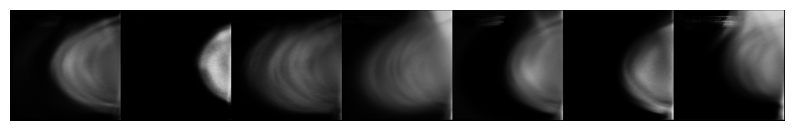

[Epoch 276/300] [D loss: -25.266891] [G loss: -4.888141]
[Epoch 277/300] [D loss: -28.861368] [G loss: -8.367132]
[Epoch 278/300] [D loss: -18.286259] [G loss: -7.812746]
[Epoch 279/300] [D loss: -23.643230] [G loss: -4.181771]
[Epoch 280/300] [D loss: -18.835621] [G loss: -10.232016]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


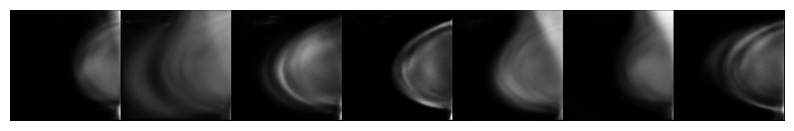

[Epoch 281/300] [D loss: -22.117416] [G loss: -8.943151]
[Epoch 282/300] [D loss: -24.479149] [G loss: -9.049088]
[Epoch 283/300] [D loss: -19.021042] [G loss: -7.553193]
[Epoch 284/300] [D loss: -22.092321] [G loss: -6.433691]
[Epoch 285/300] [D loss: -19.915966] [G loss: -9.630625]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


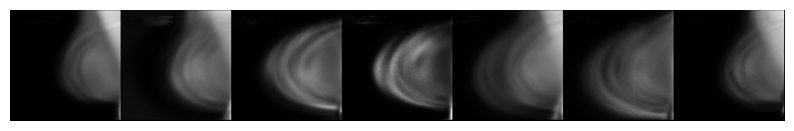

[Epoch 286/300] [D loss: -18.229298] [G loss: -11.058716]
[Epoch 287/300] [D loss: -21.150349] [G loss: -11.504934]
[Epoch 288/300] [D loss: -19.286190] [G loss: -9.428988]
[Epoch 289/300] [D loss: -23.098701] [G loss: -9.406730]
[Epoch 290/300] [D loss: -22.427429] [G loss: -12.398951]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


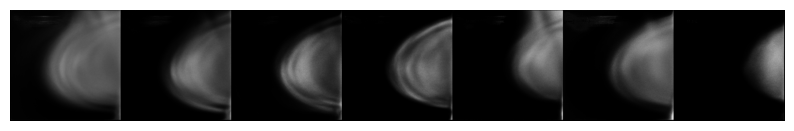

[Epoch 291/300] [D loss: -21.710865] [G loss: -5.515339]
[Epoch 292/300] [D loss: -17.720495] [G loss: -7.707311]
[Epoch 293/300] [D loss: -18.350174] [G loss: -11.640907]
[Epoch 294/300] [D loss: -20.395172] [G loss: -1.443523]
[Epoch 295/300] [D loss: -27.792690] [G loss: -10.850790]
Generated images shape: torch.Size([7, 1, 1, 256, 256])


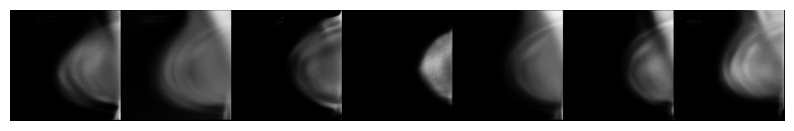

[Epoch 296/300] [D loss: -21.957859] [G loss: -10.724438]
[Epoch 297/300] [D loss: -18.183506] [G loss: -4.273710]
[Epoch 298/300] [D loss: -12.684477] [G loss: -9.070867]
[Epoch 299/300] [D loss: -21.502447] [G loss: -8.570366]
[Epoch 300/300] [D loss: -22.649860] [G loss: -8.350231]


In [45]:
import torch
from torch.autograd import Variable
import numpy as np

checkpoint_interval = 10

# Set the device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image shape and model setup
img_shape = (1, img_size, img_size)

# Instantiate models and move them to the GPU
generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
discriminator = Discriminator(img_shape=img_shape).to(device)

# Define optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(b1, b2))

# Learning Rate Scheduler (Cosine Annealing)
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=n_epochs)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=n_epochs)

# Gradient penalty function
def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty loss for WGAN GP"""
    alpha = torch.tensor(np.random.random((real_samples.size(0), 1, 1, 1)), dtype=torch.float32, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)

    fake = Variable(torch.ones(real_samples.shape[0], 1, dtype=torch.float32, device=device), requires_grad=False)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# ----------
#  Training
# ----------

batches_done = 0
d_loss_val = 0
g_loss_val = 0

for epoch in range(1,n_epochs+1):
    if epoch % 5 == 1:
        generate_and_display_images(generator, num_images=7, latent_dim=latent_dim, nrow=7, device=device)
    for i, imgs in enumerate(dataloader):

        # Ensure the tensors are float32 and move to device
        real_imgs = Variable(imgs.type(torch.float32).to(device))

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Sample noise as generator input
        z = Variable(torch.tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim)), dtype=torch.float32).to(device))

        # Generate a batch of images
        fake_imgs = generator(z)

        # Reshape fake images to match the shape of real images
        fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

        # Real images
        real_validity = discriminator(real_imgs)
        # Fake images
        fake_validity = discriminator(fake_imgs)
        # Gradient penalty
        gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, fake_imgs.data)
        # Adversarial loss
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty

        # Apply gradient clipping
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)

        # Backprop and optimizer step
        d_loss.backward()
        d_loss_val = d_loss.item()

        optimizer_D.step()

        optimizer_G.zero_grad()

        # Train the generator every n_critic steps
        if i % n_critic == 0:

            # -----------------
            #  Train Generator
            # -----------------

            # Generate a batch of images
            fake_imgs = generator(z)

            # Reshape fake images to match the shape of real images
            fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

            # Loss measures generator's ability to fool the discriminator
            # Train on fake images
            fake_validity = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_validity)

            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)

            # Backprop and optimizer step
            g_loss.backward()
            optimizer_G.step()

            # print(
            #     "[Epoch %d/%d] [Batch %d/%d] [D loss: %f] [G loss: %f]"
            #     % (epoch, n_epochs, i, len(dataloader), d_loss.item(), g_loss.item())
            # )
            g_loss_val = g_loss.item()

            if batches_done % sample_interval == 0:
                save_image(fake_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)

            batches_done += 1

        # Step the schedulers (learning rate adjustment)
        scheduler_G.step()
        scheduler_D.step()

        # Optional: Save checkpoint of model periodically (every few epochs)
        if epoch % checkpoint_interval == 0 and i == len(dataloader) - 1:
            torch.save(generator.state_dict(), 'generator_checkpoint.pth')
            torch.save(discriminator.state_dict(), 'discriminator_checkpoint.pth')

    print("[Epoch %d/%d] [D loss: %f] [G loss: %f]"
             % (epoch, n_epochs, d_loss_val, g_loss_val)
            )